In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from urllib.request import Request, urlopen

In [2]:
def imread_url(url: str, flags=cv2.IMREAD_COLOR):
    req = Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urlopen(req) as resp:
        data = resp.read()
    img = cv2.imdecode(np.frombuffer(data, np.uint8), flags)
    if img is None:
        raise ValueError(f"Failed to decode image from URL: {url}")
    return img

# Prewitt Filter test

In [3]:
# img = 'https://assets.bwbx.io/images/users/iqjWHBFdfxIU/iVwpG9Juin.Q/v0/-1x-1.webp'
img = 'https://images.squarespace-cdn.com/content/v1/605aa57db04a457a373a2fdc/1618291122347-21AC5VQQWSFO7X6JJ3TA/octavia%2B3200.png'

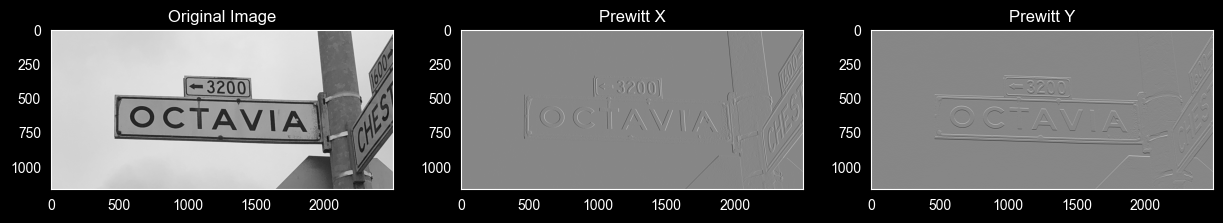

In [4]:
bgr = imread_url(img, cv2.IMREAD_COLOR)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

# Prewitt (custom kernels)
kernelx = np.array([[ -1, 0, 1],
                    [ -1, 0, 1],
                    [ -1, 0, 1]], dtype=np.float32)
kernely = np.array([[  1,  1,  1],
                    [  0,  0,  0],
                    [ -1, -1, -1]], dtype=np.float32)

g_x = cv2.filter2D(gray, cv2.CV_32F, kernelx)
g_y = cv2.filter2D(gray, cv2.CV_32F, kernely)

# Draw Original, Prewitt X and Prewitt Y
ax, fig = plt.subplots(1,3, figsize=(15,15))

fig[0].imshow(gray, cmap='gray')
fig[0].set_title('Original Image')
fig[1].imshow(g_x, cmap='gray')
fig[1].set_title('Prewitt X')
fig[2].imshow(g_y, cmap='gray')
fig[2].set_title('Prewitt Y')
for ax in plt.gcf().axes:
    ax.grid(False)
plt.show()

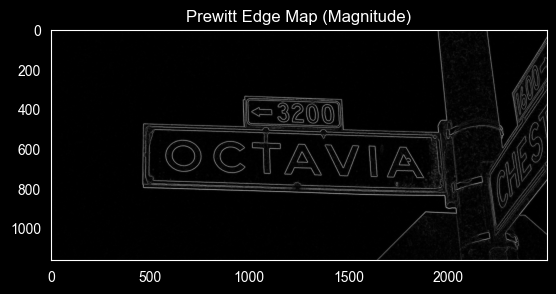

In [5]:
# Combine (gradient magnitude)
magnitude = cv2.magnitude(g_x, g_y)

# Normalize for visualization
magnitude = cv2.normalize(
    magnitude, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

plt.imshow(magnitude, cmap='gray')
plt.grid(False)
plt.title('Prewitt Edge Map (Magnitude)')
plt.show()

# Sobel Filter test

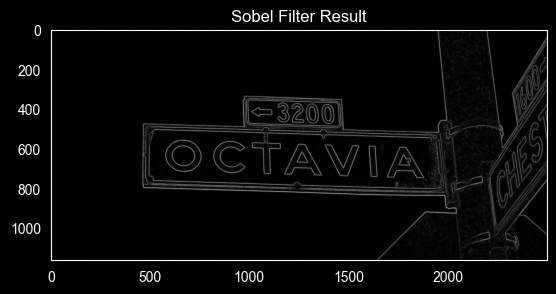

In [48]:
bgr = imread_url(img, cv2.IMREAD_COLOR)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

# Sobel
grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)


# Compute magnitude
multiplier = 2
grad = np.sqrt(grad_x**multiplier + grad_y**multiplier)
grad = grad/np.max(grad)
sobel = grad.copy()

plt.imshow(grad, cmap='gray')
plt.grid(False)
plt.title('Sobel Filter Result')
plt.show()

# Edge Map Filter test

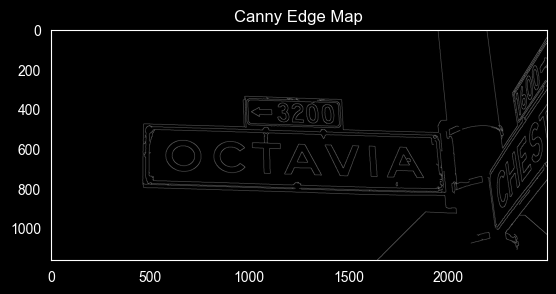

In [44]:
bgr = imread_url(img, cv2.IMREAD_COLOR)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 100, 300)

plt.imshow(edges, cmap='gray')
plt.grid(False)
plt.title('Canny Edge Map')
plt.show()

# Laplacian Filter test

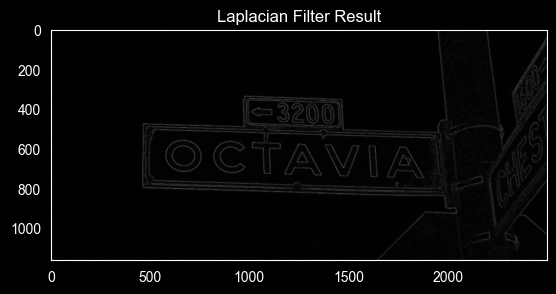

In [6]:
bgr = imread_url(img, cv2.IMREAD_COLOR)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

plt.imshow(laplacian, cmap='gray')
plt.grid(False)
plt.title('Laplacian Filter Result')
plt.show()

### Hough Transform

(<Axes: >, <matplotlib.image.AxesImage at 0x1ca83313750>, None)

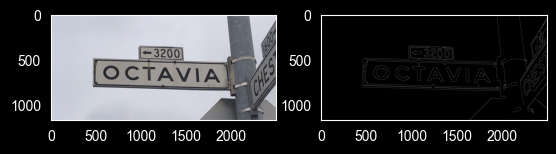

In [34]:
bgr = imread_url(img, cv2.IMREAD_COLOR)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, threshold1=100, threshold2=400)

plt.subplot(121), plt.imshow(rgb), plt.grid(False)
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.grid(False)

(<Axes: >, <matplotlib.image.AxesImage at 0x1ca95cad450>, None)

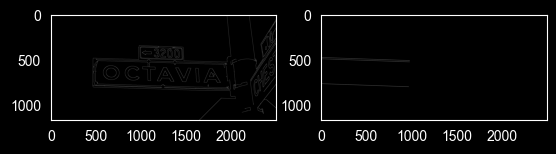

In [42]:
import math

lines = cv2.HoughLines(edges,
                       rho=5, # Distance resolution in pixels
                       theta=2*np.pi/180, # Angle resolution in radians
                       threshold=50) # Min number of votes
hough = np.zeros_like(edges)

for i in range(0, len(lines[0:3])):
    rho = lines[i][0][0]
    theta = lines[i][0][1]
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * a))
    pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * a))
    cv2.line(hough, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.grid(False)
plt.subplot(122), plt.imshow(hough, cmap='gray'), plt.grid(False)